# 常见WorkFlow
上一节学习了LangGraph的Node、Edge、State三要素，知道了如何构建Agent，但LangGraph的能力并不在于构建简单的Agent，而是用图的方式灵活编排任意复杂的工作流。

本节深入学习各种常见的流程编排模式。

本节将学习七种核心编排模式：
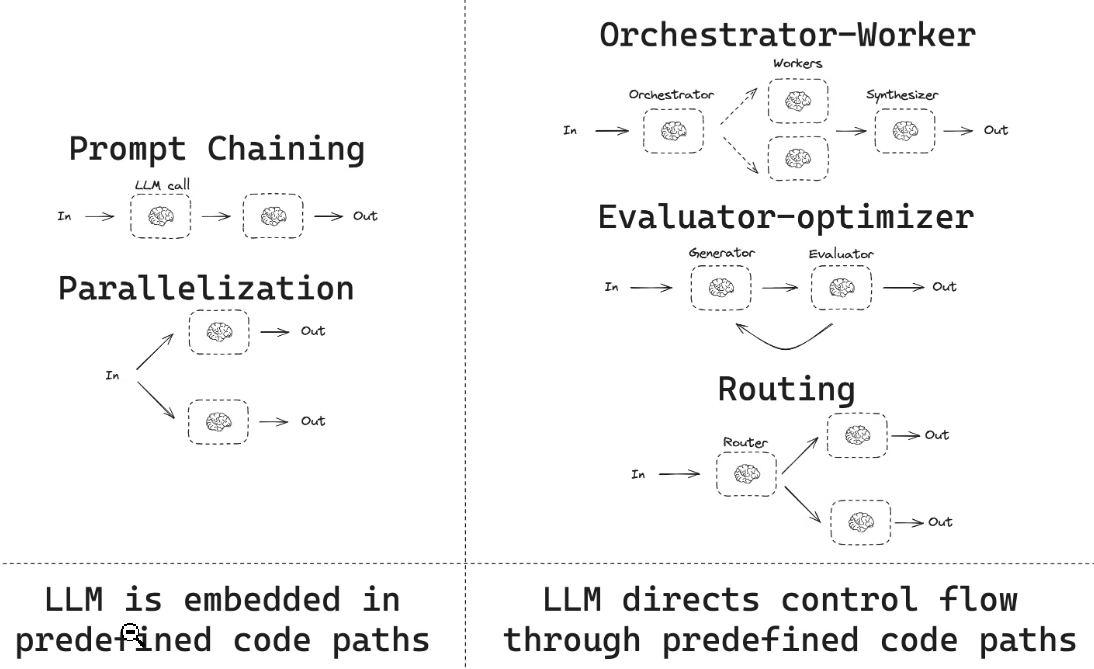

左侧的两个：LLM嵌入到了预定义的工作流当中，用于你明确知道工作流程的场景。
右侧的三个：由LLM来控制工作流，更智能化。

本章会用到的依赖和工具：

In [1]:
from typing import Annotated, TypedDict, Literal, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, CachePolicy, interrupt, Send
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy, TimeoutPolicy
from langgraph.errors import NodeError
from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from IPython.display import Image, display
from operator import add
from dotenv import load_dotenv
from pydantic.dataclasses import dataclass
from pydantic import BaseModel, Field

load_dotenv()

def display_graph(graph, xray=False):
    """显示图结构，xray=True 可展开子图内部结构"""
    display(Image(graph.get_graph(xray=xray).draw_mermaid_png()))

llm = init_chat_model("deepseek-chat")

## 1. 顺序执行（Prompt Chaining）

Prompt Chaining 是最基础的编排模式：前一个LLM的输出作为后一个LLM的输入，像流水线一样串联起来。

典型场景: 写作流程（大纲→初稿→润色）、翻译+校对、分步推理。

与直接 LLM 调用的区别: 顺序链可以在步骤之间加入验证门控（Gate）——如果某步质量不达标就退回重做，而不是一路到底。
比如，一个写笑话的工作流。
示意图：
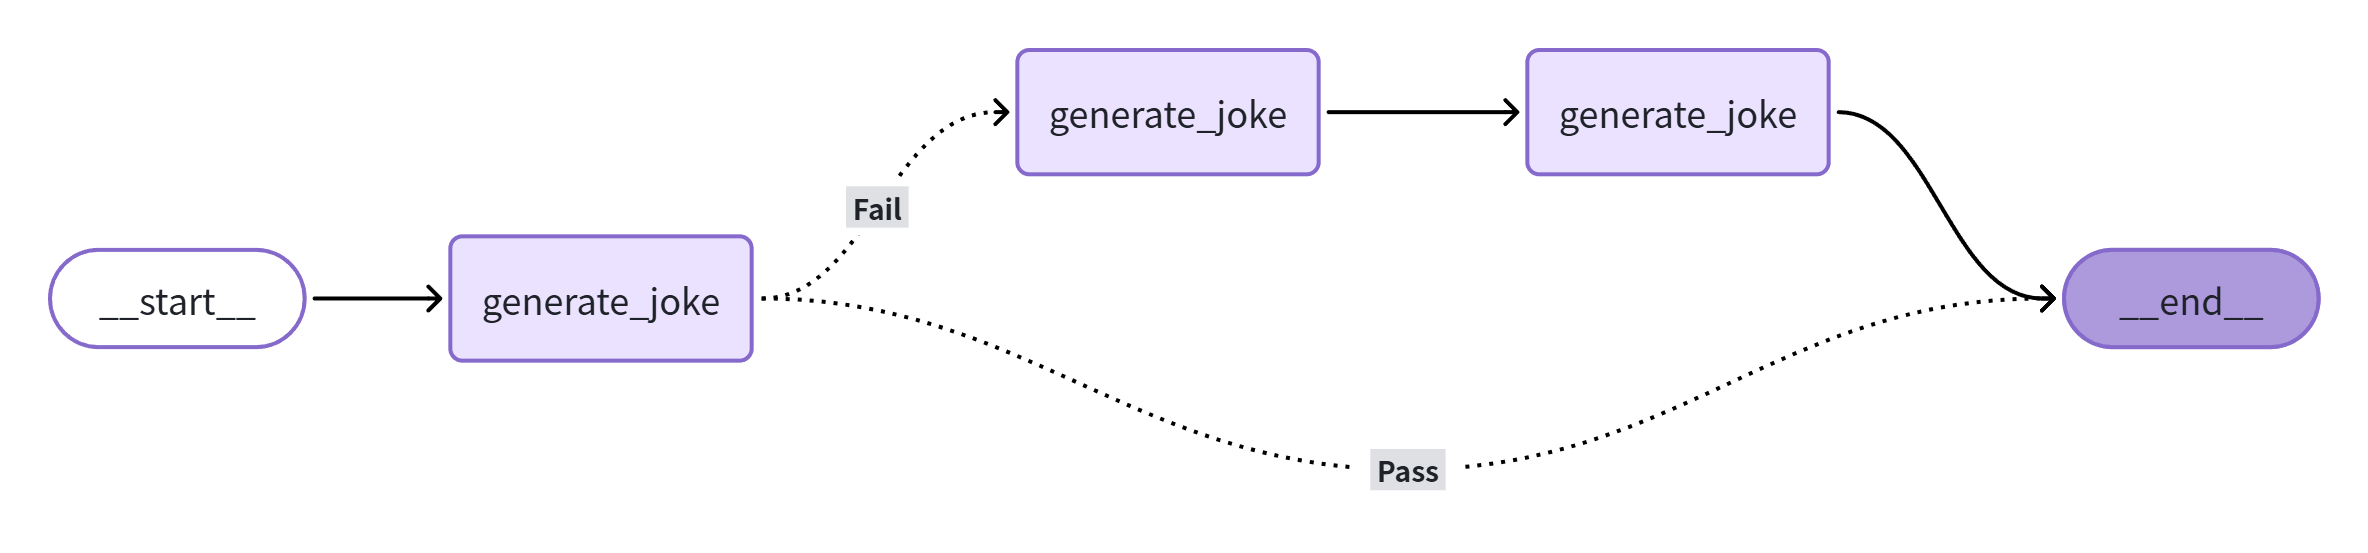

In [2]:
# Prompt Chaining: 生成笑话 → 检查质量 → 润色 → 加梗
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

class JokeState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

def generate_joke(state: JokeState):
    """步骤1: 生成初稿"""
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content, "final_joke": msg.content}

def check_punchline(state: JokeState):
    """门控函数：检查笑话是否有笑点"""
    msg = llm.invoke(f"Check if the joke has punchline and wordplay, return 'Pass' or 'Fail' for the joke: ```{state['joke']}```")

    result = msg.content
    if "Pass" == result:
        print(f"  [检查] 通过 ✓")
        return "Pass"
    print(f"  [检查] 不通过 ✗")
    return "Fail"

def improve_joke(state: JokeState):
    """步骤2: 改进——增加双关语"""
    print(f"  [润色] 添加双关语...")
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: JokeState):
    """步骤3: 润色——加一个反转"""
    print(f"  [润色] 添加反转...")
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}

# 构建图
chaining_graph = (
    StateGraph(JokeState)
    .add_node("generate_joke", generate_joke)
    .add_node("improve_joke", improve_joke)
    .add_node("polish_joke", polish_joke)
    .add_edge(START, "generate_joke")
    # 条件边：通过则直接结束，不通过则进入改进流程
    .add_conditional_edges(
        "generate_joke",
        check_punchline,
        {"Pass": END, "Fail": "improve_joke"}
    )
    .add_edge("improve_joke", "polish_joke")
    .add_edge("polish_joke", END)
    .compile()
)

print("=== 测试1: 话题「大树」 ===\n")
r = chaining_graph.invoke({"topic": "大树", "joke": "", "improved_joke": "", "final_joke": ""})
print(f"\n最终笑话:\n{r['final_joke']}")

=== 测试1: 话题「大树」 ===

  [检查] 不通过 ✗
  [润色] 添加双关语...
  [润色] 添加反转...

最终笑话:
大树话音刚落，突然狂风大作，一棵小树苗连根拔起，滚到它脚边，哭丧着脸说：“大哥，您别抱怨了！我刚学会摇摆，就被发配到‘绿化带拆迁办’——说是要给我挪窝，结果挖机一铲下去，我直接变成了‘树生简历’，上面写着：特长——挡风，缺点——没长成顶梁柱。”


## 2. 并行执行（Parallelization）

通过并行化，可以让多个LLM同时处理一个任务，有两种不同的实现方式和作用：
- 提高效率: 将任务拆分为子任务，让多个LLM同时运行独立的子任务来完成，再汇总结果
- 提高准确度: 多个LLM运行相同的任务产生不同的输出，再合并优化结果
```mermaid
flowchart LR
    start["__start__"] --> task1[task_1]
    start --> task2[task_2]
    start --> task3[task_3]
    task1 --> aggregator
    task2 --> aggregator
    task3 --> aggregator
    aggregator --> end1["__end__"]
```
比如，我需要同时基于某个话题写三种题材：
- 笑话
- 故事
- 诗歌
并行执行的话效率会更高，示例代码：

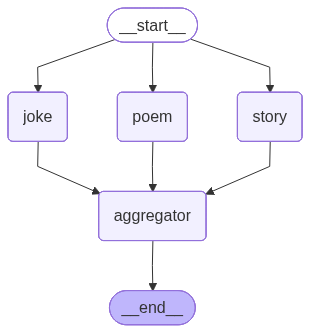

In [4]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

# Nodes
def joke_node(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def story_node(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a short story about {state['topic']}")
    return {"story": msg.content}

def poem_node(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a short poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("joke", joke_node)
parallel_builder.add_node("story", story_node)
parallel_builder.add_node("poem", poem_node)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "joke")
parallel_builder.add_edge(START, "story")
parallel_builder.add_edge(START, "poem")
parallel_builder.add_edge("joke", "aggregator")
parallel_builder.add_edge("story", "aggregator")
parallel_builder.add_edge("poem", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display_graph(parallel_workflow)

In [5]:
# Invoke
state = parallel_workflow.invoke({"topic": "程序员"})
print(state["combined_output"])

Here's a story, joke, and poem about 程序员!

STORY:
The fluorescent lights of the office hummed a monotonous lullaby. Li Wei, a senior developer, was the only soul left in the 24th floor, his desk a small island of warm light in a sea of gray cubicles. The air smelled of stale coffee and ozone. He was fighting a bug.

It wasn't just any bug. This one was a ghost. A null pointer exception that only appeared in production, on the third Tuesday of the month, at exactly 2:14 PM, for users in the "Mountain Time" zone. It was a digital cockroach that knew the exact layout of the kitchen’s dark corners.

For eight hours, he had been a surgeon, a detective, a historian of his own code. He’d traced variables like bloodlines, reconstructed object lifecycles like ancient genealogies, and stared at logs until the numbers bled into each other. Nothing. The bug was a perfect, silent void.

His eyes burned. He leaned back, the cheap office chair groaning in protest. He looked out the window. Beijing wa

## 3. 路由（Routing)
Routing工作流处理用户输入，然后将它们引导到上下文相关的任务Node。这允许您为复杂的任务定义专门的流。例如：
- 智能电商客服，首先识别问题的类型，然后将请求路由到 售前咨询、退款、退货等对应的Node。
- 知识问答机器人，首先识别问题知识领域，然后将请求路由到不同领域对应的专业Node上。

所以路由本质上也是条件分支，让Graph根据问题动态选择下一节点。这是Agent智能决策的核心机制。
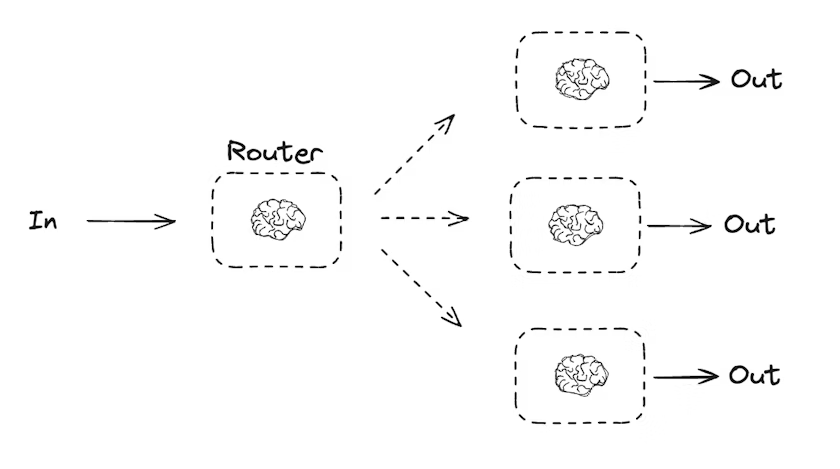
例如，我们写三个工作节点：
- 天气节点：可以查询天气
- 新闻节点：可以查询新闻
- 翻译节点：可以翻译

然后写一个意图识别节点，根据用户意图路由到对应的工作节点，执行对应任务：

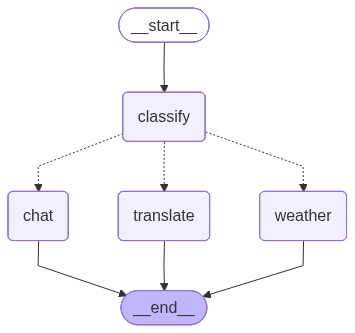

In [6]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage


# 定义作为路由逻辑的结构化输出模型
class Route(BaseModel):
    step: Literal["weather", "translate", "chat"] = Field(
        None, description="The next step in the routing process"
    )
# 把路由结构化输出绑定到模型，形成一个用于路由的llm
router = llm.with_structured_output(Route)

class IntentState(TypedDict):
    query: str
    intent: str
    result: str

def classify_intent(state: IntentState):
    """分类用户意图"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to weather, translate, or chat based on the user's request."
            ),
            HumanMessage(content=state["query"]),
        ]
    )

    return {"intent": decision.step}

def handle_weather(state: IntentState):
    return {"result": f"天气查询: {state['query']} -> 晴 25度"}

def handle_translate(state: IntentState):
    return {"result": f"翻译: {state['query']} -> Hello World"}

def handle_chat(state: IntentState):
    return {"result": f"闲聊: {state['query']} -> 你好呀！"}

def intent_router(state: IntentState) -> Literal["weather", "translate", "chat"]:
    """根据意图路由到不同处理器"""
    return state["intent"]

routing_graph = (
    StateGraph(IntentState)
    .add_node("classify", classify_intent)
    .add_node("weather", handle_weather)
    .add_node("translate", handle_translate)
    .add_node("chat", handle_chat)
    .add_edge(START, "classify")
    .add_conditional_edges("classify", intent_router, {
        "weather": "weather",
        "translate": "translate",
        "chat": "chat"
    })
    .add_edge("weather", END)
    .add_edge("translate", END)
    .add_edge("chat", END)
    .compile()
)

display_graph(routing_graph)

In [7]:

# 测试三种意图
for q in ["今天北京天气如何？", "翻译hello", "你好吗？"]:
    r = routing_graph.invoke({"query": q, "intent": "", "result": ""})
    print(f"'{q}' -> intent={r['intent']} -> {r['result']}")

'今天北京天气如何？' -> intent=weather -> 天气查询: 今天北京天气如何？ -> 晴 25度
'翻译hello' -> intent=translate -> 翻译: 翻译hello -> Hello World
'你好吗？' -> intent=chat -> 闲聊: 你好吗？ -> 你好呀！


## 4. Orchestrator-Worker + Send API
Orchestrator-Worker，顾名思义，编排器—工作者模型。分为三个步骤：
- 编排器（Orchestrator）：将任务分解为子任务，将子任务分配给worker
- 工作节点（Worker）：并行执行任务
- 合成器（Synthesizer）：将worker的输出汇总为最终结果
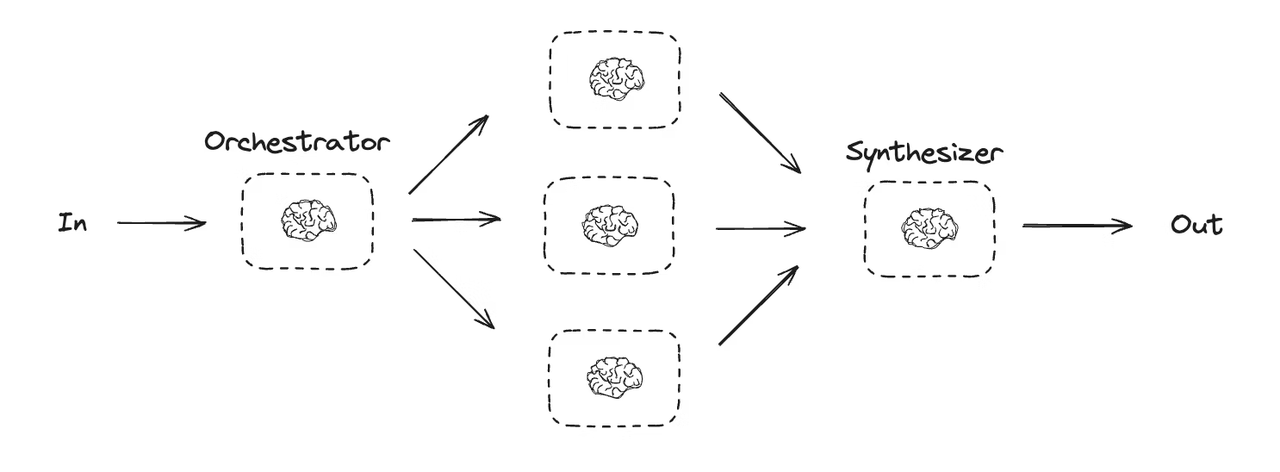
这听起来似乎与之前讲的并行模式很像，没错这确实也属于并行模式。但不同之处在于：
- 普通并行工作流：任务是需要手动拆分的，且子任务数量是固定的
- Orchestrator-Worker：是用模型动态的将复杂任务拆分为多个并行子任务，子任务数量不确定

### 4.1 Send API
Orchestrator-Worker模式提供了更高的灵活性，通常用于无法像并行化那样预先定义子任务的场景。例如：AI编程助手、深度研究助手

我们以深度研究助手（DeepResearcher）为例，它可以根据你指定的话题写出专业报告：
- 首先，需要根据话题生成报告大纲，细分出多个章节，定好每个章节主题
- 然后，把每个章节作为一个子任务，交给多个工作进程并行执行
- 最后，汇总所有子任务生成的章节，得到完整的研究报告


但是，这里有一个很严重的问题：
子任务的数量是不确定的，因此Node没办法提前定义好，那该如何设计Graph？

不用担心，LangGraph 对此提供了内置支持。通过 Send API，你可以动态创建工作节点并向它们发送特定的输入。每个工作节点都有自己的State，而且所有工作节点的输出都会被写入一个共享的State 字段中，编排器图可以访问该字段。这使得编排器能够获取所有工作节点的输出，并将其整合成最终输出。

在深度研究助手案例中，我们可以遍历计划好的章节列表，并使用 Send API 将每个章节发送给对应的工作节点。

### 4.2 DeepResearcher示例
接下来就开发一个用于生成报告的深度研究助手：DeepResearcher

#### 4.2.1 结构化输出模型
首先，我们定义模型类，作为结构化输出的约束，让LLM按照固定格式生成拆分的章节列表：

In [8]:
from typing import Annotated, List
import operator


# 用于记录子任务信息的 结构化输出模型
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# 将模型与structured output模型绑定，这个模型就用来拆分任务
planner = llm.with_structured_output(Sections)

#### 4.2.2 State
接着，是State，工作过程中产生的章节信息和报告信息：

In [9]:
# 编排者的 State ，记录完整信息
class State(TypedDict):
    topic: str  # 报告主题
    sections: list[Section]  # 报告的章节列表
    completed_sections: Annotated[
        list, operator.add
    ]  # 所有工作线程并行地把报告写入这个字段
    final_report: str  # 最终报告


# Worker的State，记录自己的任务进度
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


#### 4.2.3 Normal Node
然后，是Node，包括
- 编排者节点：Orchestrator
- 工作节点：Worker
- 合成器节点：Synthesizer

In [10]:
# 编排者节点
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # 通过SystemPrompt设定和结构化输出绑定，让LLM作为orchestrator
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}

# 工作节点，工作节点只能有1个，原因如下：
#  1.工作的代码逻辑是一样的，只是子任务不同
#  2.子任务数量不确定，无法提前给每个子任务写一个Node
# 我们会利用Send API来分发子任务给这个节点，让它产生“分身”效果，可以并行处理多个任务
def worker(state: WorkerState):
    """Worker writes a section of the report"""

    # 通过Prompt的设定，让llm根据子任务编写报告的部分章节
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# 合成器节点，用于合并最终结果
def synthesizer(state: State):
    """Synthesize full report from sections"""

    # 拿到Worker返回的结果
    completed_sections = state["completed_sections"]

    # 将完成的部分格式化为str，用作最后部分的上下文
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

#### 4.2.4 派发任务的Node
接下来是关键的任务派发节点，我们需要遍历由Orchestrator计划好的章节列表，并使用 Send API 将每个章节发送给对应的工作节点。

In [11]:
from langgraph.types import Send

# Conditional edge Node，根据编排者安排的子任务创建llm_call工作者，每个工作者编写报告的一个部分
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # 通过Send() API分发任务给Worker，让Worker并行写报告的不同章节
    return [Send("worker", {"section": s}) for s in state["sections"]]

注意Send接收的两个参数：
- worker：工作节点的名字
- {"section": s}: 是传入的State，这里是章节信息

#### 4.2.5 创建Graph
最后，就是组织Graph了：

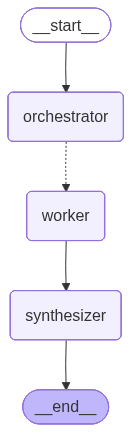

In [12]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("worker", worker)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["worker"]
)
orchestrator_worker_builder.add_edge("worker", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker_graph = orchestrator_worker_builder.compile()

# Show the workflow
display_graph(orchestrator_worker_graph)

这个结构图看起来很奇怪，只有一个worker，但其实worker的数量是动态的，由报告规划的章节数量决定。

### 4.2.6 测试

In [13]:
# Invoke
state = orchestrator_worker_graph.invoke({"topic": "创建一份关于LLM scaling laws的报告"})

from IPython.display import Markdown
Markdown(state["final_report"])

## 引言

近年来，大语言模型（Large Language Models, LLMs）取得了突破性进展，从GPT系列到Claude、Gemini等模型，其能力在文本生成、推理、编程等多个领域表现出色。这一成功背后，关键驱动力之一是对模型规模、数据量与计算资源之间关系的深入理解，即所谓的“LLM Scaling Laws”（大语言模型缩放定律）。缩放定律揭示了随着模型参数数量、训练数据规模和计算预算的增加，模型性能会呈现可预测的幂律提升。这一发现不仅引导了产业界大规模训练模型的方向，也为学术研究和资源分配提供了理论基础。

然而，缩放定律并非万能。随着模型规模持续膨胀，边际收益递减、数据稀缺性、训练成本激增等问题日益凸显。因此，重新审视缩放定律的背景、核心发现及其适用边界，对于指导未来LLM的发展具有重要的理论和实践意义。本报告旨在系统梳理LLM Scaling Laws的提出背景、关键公式与实验结果，分析其在实际应用中的有效性和局限性，并展望未来研究挑战与方向。

报告结构如下：第2章回顾缩放定律的核心理论和主要实证发现；第3章讨论其在模型训练、数据处理和资源优化中的应用；第4章分析缩放定律的局限性与当前争议；第5章总结全文并提出未来展望。通过这一结构，我们希望为读者提供关于LLM Scaling Laws全面而深入的理解。

---

### Scaling Laws的基本概念

**定义**  
Scaling Laws（规模定律）描述了深度学习模型性能与模型规模（参数数量）、数据规模（训练样本量）及计算量（FLOPs或GPU小时）之间的量化关系。核心观点是：在合理的训练条件下，模型性能（如测试损失）会随着这三者的增长而呈现幂律（power-law）提升，而非线性增长。

**三要素关系**  
1. **模型规模与性能**：增加参数数量（例如从1亿到1000亿）可显著降低损失，但存在边际递减效应——每次参数翻倍带来的收益递减，提升幅度正比于参数量的负指数。  
2. **数据规模与性能**：训练数据量越大，模型泛化能力越强，性能提升同样遵循幂律——数据量翻倍时损失下降幅度按固定比例缩减。若数据规模不足，模型将陷入欠拟合。  
3. **计算量与性能**：总计算量（由参数数量×训练数据量决定）与性能直接挂钩。固定计算预算时，存在最优分配：模型规模和训练数据需按特定比例增长（即参数与数据量应等比例扩展），否则会造成资源浪费（如参数过多但数据不足导致过拟合）。  

**核心结论**  
- **联合缩放（Joint Scaling）**：要持续提升模型性能，模型规模、数据规模和计算量必须同步扩大。例如，参数翻倍时，训练数据量也需大致翻倍，以保持损失下降趋势。  
- **不可绕过性**：缩放定律揭示了模型的硬性瓶颈——在固定训练策略下，仅靠任意单一维度的提升（如无限增大模型）很快会遇到回报递减，需三要素协同增长才能突破饱和点。

---

### 核心发现与定律

Kaplan 等人（2020）在“Scaling Laws for Neural Language Models”中系统性地揭示了大规模语言模型的关键缩放规律，这些规律以幂律关系（Power Laws）为核心，描述了模型性能（以交叉熵损失衡量）与三个关键因素之间的定量关系：模型参数量（N）、训练数据量（D）和计算预算（C，以 FLOPs 计）。这些定律为模型设计和资源分配提供了理论基础。

#### 1. 损失与模型参数量的关系

在固定数据量（即数据量足够多，不成为瓶颈）的条件下，测试损失（Loss）与模型参数量（N）之间存在幂律关系：
\[
L(N) \approx \left( \frac{N_c}{N} \right)^{\alpha_N}
\]
其中，\(N_c\) 是一个归一化常数，\(\alpha_N\) 是幂律指数（约为 0.076）。这意味着增加模型参数可以降低损失，但收益递减——参数量每增加一个数量级，损失下降的幅度逐渐减少。例如，参数量从 1M 增至 10M，损失下降明显，但从 100M 增至 1B，改进幅度变小。这一关系表明，在数据充足时，大模型更高效，但不应该无限扩大参数量而不考虑数据。

#### 2. 损失与数据量的关系

在固定模型参数量的条件下，测试损失与训练数据量（D，以 token 数计）同样满足幂律关系：
\[
L(D) \approx \left( \frac{D_c}{D} \right)^{\alpha_D}
\]
指数 \(\alpha_D\) 约为 0.095。这意味着增加数据量也能降低损失，但同样收益递减。当数据量很小时，增加数据对性能提升显著；当数据量极大时，额外数据带来的收益微乎其微。这一关系强调，数据量是模型性能的重要决定因素，但存在饱和点。

#### 3. 损失与计算量的关系

实际应用中，通常考虑计算预算（C）固定时如何优化模型性能。计算预算可近似表示为：
\[
C \approx 6 \cdot N \cdot D
\]
（假设训练过程中 forward 和 backward 的计算量大致与参数量和 token 数乘积成正比）。在给定计算预算 C 下，最优损失满足另一个幂律关系：
\[
L(C) \approx \left( \frac{C_c}{C} \right)^{\alpha_C}
\]
指数 \(\alpha_C\) 约为 0.054。这表明，当计算预算增加时，损失呈幂律下降，但效率递减。更重要的是，这一关系提供了最优资源分配策略：在计算预算固定时，参数和数据的最优比例并非随意，而是必须平衡。Kaplan 等人发现，**模型参数量和数据量应同步增长**——计算预算增加 10 倍，最优参数量约增加 5 倍，最优数据量约增加 2 倍。这表明，通过仅增大模型或仅增加数据都是次优的，必须按特定比例共缩放。

#### 4. 多项式拟合与共缩放关系

以上三个定律并非独立，而是通过统一的幂律形式联系在一起。Kaplan 等人将损失函数建模为所有三个变量的函数（假设训练充分，无收敛限制）：
\[
L(N, D) = \left[ \left( \frac{N_c}{N} \right)^{\alpha_N / \beta} + \left( \frac{D_c}{D} \right)^{\alpha_D / \beta} \right]^{\beta}
\]
其中 \(\beta\) 是一个调节两种偏差相互作用的参数。这一形式表明，参数和数据对损失的贡献是可加（或可乘）的，且共同决定了最终性能。当计算预算固定时，最优分配由这一关系导出，从而得到损失与计算量的幂律。

#### 5. 关键结论与意义

- **性能的可预测性**：幂律关系使得基于小模型和少量数据的实验结果可以外推到大规模场景，为 GPT-3 等大模型的选型提供了理论依据。
- **资源效率**：当计算预算有限时，模型参数和数据量需要按比例增长，而不是单方面扩大参数规模。例如，对于一个 100M 参数模型，若计算预算增加 10 倍，不应只将参数增至 1B 而保持数据不变，而应同时增加数据和参数。
- **规模上限**：这些定律并不永久成立——在某些极端情况下（如数据重复利用或模型超过一定规模），可能会出现偏离。但它们为当前大型语言模型设计提供了关键指导。

总之，Kaplan 等人的幂律定律揭示了模型、数据与计算之间的确定性关系，表明在现有技术框架下，模型性能的提升可以通过可控的规模化实现，但受制于收益递减规律。后续研究（如 Chinchilla Scaling Laws）进一步修正了这些指数，但幂律核心仍被广泛认可。

---

### Chinchilla Scaling Laws

DeepMind’s Chinchilla study redefined the principles of scaling large language models by introducing the concept of **compute-optimal training**. Prior work, such as Kaplan et al.’s scaling laws, suggested that increasing model size alone was the primary driver of performance gains. However, Chinchilla demonstrated that for a fixed compute budget, the **optimal performance** is achieved when the **model size (number of parameters) and the amount of training data are scaled proportionally**. In other words, larger models require proportionally more data to avoid underfitting, and vice versa.

The key finding was that many existing large models (e.g., GPT-3) were significantly **overparameterized** — they had more parameters than necessary for their training data size. By training a 70B-parameter model on 1.4 trillion tokens (4× more data than typical for its size), Chinchilla matched or outperformed much larger models (e.g., Gopher with 280B parameters) using the same compute budget. This established the **Chinchilla Ratio**: for compute-optimal training, the number of tokens should scale approximately **20× the number of parameters**.

This insight has critical implications: it shifts the focus from building ever-larger models to investing in large, high-quality datasets. It also suggests that many prior scaling laws were data-limited underestimates. Practically, compute-optimal training reduces waste — smaller models trained on more data can achieve the same performance as huge models on less data, saving computational resources and improving efficiency. The Chinchilla laws have become a standard benchmark for designing both model architecture and data collection strategies in modern NLP.

---

### 数据Scaling的影响

#### 1. 数据质量对Scaling效果的影响
数据质量是决定模型性能的基石。高质量数据（如经过清洗、标注准确、内容无噪声）能显著提升模型在下游任务上的泛化能力与鲁棒性。研究表明，使用更高质量的数据，通常能以更少的训练步数或更小的模型规模达到与低质量数据等同甚至更优的效果。数据质量包括：  
- **标注一致性**：错误或不一致的标注会导致模型学习到错误映射，削弱Scaling带来的收益。  
- **内容清晰度**：模糊、噪声大或格式混乱的数据会引入干扰，迫使模型浪费容量在无关模式上。  
- **信息密度**：每条样本的信息含量越高，Scaling效率越高；冗余低信息样本则会稀释模型学习能力。

#### 2. 数据重复对Scaling效果的影响
数据重复（指相同或高度相似的样本多次出现）对Scaling行为具有双重影响。  
- **正面作用**：适度重复关键或困难样本可强化记忆，提升特定任务上的表现（如对话模板、常见实体识别）。  
- **负面作用**：过度重复会造成模型过拟合，导致训练损失下降但验证损失不降甚至上升。同时，重复数据会压缩模型对多样性的学习，使得Scaling定律中的效果曲线提前进入饱和区。  
实践中，通常采用去重策略（如基于哈希、嵌入向量相似度去重）确保训练集中样本的唯一性或控制重复率在合理阈值内。

#### 3. 数据多样性对Scaling效果的影响
数据多样性是维持Scaling收益递增的核心条件。多样性体现在：  
- **领域覆盖**：涵盖广泛的主题、语言、格式与任务类型，防止模型在特定分布上过拟合，从而提升通用能力。  
- **难度分布**：包含难易程度不等的样本，避免模型仅学习简单模式而忽略复杂边界。  
- **分布均衡**：长尾分布下的低频数据若被充分采样，可显著增强模型的尾部鲁棒性；反之，Scaling会倾向于放大高频模式，导致偏差加剧。  
实验表明，增加数据多样性通常比单纯扩大数据量对Scaling回报的贡献更大。若多样性不足，即使数据规模极大，模型性能也会出现天花板。

#### 4. 数据瓶颈问题
数据瓶颈是指随着模型规模和数据量的Scaling，性能提升开始减缓甚至停滞，表现为模型容量无法有效利用数据信息。常见原因包括：  
- **数据饱和**：现有数据中可提取的信号已被模型充分捕获，进一步增加数据仅带来边际递减。  
- **分布偏移**：训练与测试分布不一致时，Scaling可能放大了噪声或特化模式，导致泛化能力下降。  
- **信息冗余**：数据集中存在大量相似样本，有效信息量远低于原始规模，阻碍Scaling定律的持续有效性。  
- **算法不匹配**：模型架构或训练策略（如学习率调度、损失函数）不适合当前数据特征，使之无法高效消化新增数据。  

破解数据瓶颈的方向包括：合成高质量新数据、主动学习选择高价值样本、以及设计自适应Scaling策略（如动态调整数据配比或引入课程学习）。

---

## 计算资源与Scaling效率

### 不同计算预算下的最优分配策略

在资源受限的条件下，研究者需根据预算规模选择最优的分配方案。对于低预算（例如小于10¹⁹ FLOPs），最优策略通常是训练一个中等规模的模型（如7B参数以下），并将剩余算力用于数据质量提升或多次重复训练，以避免模型欠拟合。中预算（10¹⁹–10²¹ FLOPs）下，应考虑模型参数与训练数据的同步增长，遵循Chinchilla法则，即模型大小和训练数据token数应按比例扩展（约每1%参数增长对应1%数据增长）。高预算（超过10²² FLOPs）时，最优策略偏向于更大模型（如100B+参数），并适当增加数据多样性，因为此时计算瓶颈转向显存和通信延迟，需要结合模型并行和数据并行进行分布式训练。

### Scaling的效率边界

Scaling的效率边界由计算资源、模型容量和数据质量共同界定。当预算增长时，存在一个“最优参数-数据比”曲线，该曲线随预算增加呈亚线性扩展。效率边界可通过如下公式近似：

\[
L(N, D) = E + \frac{A}{N^\alpha} + \frac{B}{D^\beta}
\]

其中 \( L \) 为损失，\( N \) 为模型参数，\( D \) 为数据量，\( E \)、\( A \)、\( B \)、\( \alpha \)、\( \beta \) 为常数。在实践中，当预算翻倍时，最优分配下模型尺寸的增长系数约为 \( \frac{\alpha}{\alpha+\beta} \)，数据增长系数为 \( \frac{\beta}{\alpha+\beta} \)。高预算区域，由于通信和调度开销增加，实际效率偏离理论边界，出现“效率拐点”。例如，在千卡集群下，算力利用率可能从单卡的90%下降至多卡并行的60%。

### 边际收益递减现象

边际收益递减是Scaling中的核心现象：每增加单位计算资源，模型性能（如准确率或困惑度）的提升幅度逐渐缩小。这种递减遵循Power-law规律，即性能提升 \( \Delta P \propto C^{-\gamma} \)，其中 \( C \) 为计算量，\( \gamma \) 通常在0.05–0.35之间（取决于任务复杂度）。例如，在语言建模任务中，计算量从10²¹ FLOPs增加到10²² FLOPs时，困惑度改善幅度可能仅为从10²⁰到10²¹ FLOPs增幅的一半。机制上，边际收益递减源于数据分布的长尾特性：模型先学得高频规律，再拟合稀有模式，而后者需要指数级增长的算力。缓解策略包括：采用数据重采样加权稀有样本、使用专家混合模型（MoE）动态分配计算，以及结合课程学习优先训练高信息量数据。尽管如此，在极限计算预算下，收益递减最终使继续Scaling的性价比低于尝试创新架构或算法改进。

---

### 实践应用与工程挑战

在实际训练大型语言模型（LLM）的过程中，Scaling Laws 虽然提供了理论上的性能-规模关系指导，但将之落地为具体训练策略时面临诸多工程挑战。以下从学习率调度、批量大小选择及分布式训练三个维度展开讨论。

#### 学习率调度

Scaling Laws 指出最优学习率会随模型参数量的增加而变化，通常遵循幂律衰减关系。然而，在工程实践中，预热（warmup）与衰减策略的匹配至关重要：
- **线性预热**：为缓解初始大梯度导致的不稳定，小模型通常使用短预热（如 1000 步），而大模型（如 100B 参数）需要更长的预热期（如 10% 总步数），以适配其更大的参数量与梯度方差。
- **余弦衰减**：结合 Scaling Laws 所建议的持续训练收益递减特性，余弦衰减调度能平滑地调整学习率，但在实际分布式场景中，若计算集群不稳定导致中断恢复，需精确复现学习率状态，否则可能引发优化轨迹漂移。
- **Warmup-Stable-Decay 策略**：部分实践发现，在模型达到临界规模后，采用“长稳定期+小衰减”的方案（如 Chinchilla 定律），能平衡数据效率与收敛速度，但需对 batch size 与学习率联合调优。

挑战：理论最优学习率方程通常假设理想硬件与无限数据，而实际中受显存、通信开销制约，学习率需协同修正，且过大学习率易导致数值溢出（如 FP16 训练时梯度丢失）。

#### 批量大小选择

Scaling Laws 揭示模型吞吐量大致与总计算量线性相关，但批量大小（batch size）的选择直接影响训练效率与收敛速度：
- **临界批量大小**：根据 Scaling Laws，过大 batch size 会降低样本效率，因梯度噪声方差减小导致收敛步数增加。实际中常通过 **梯度累积** 实现显存限制下的等效大 batch（如 8M tokens），但带来迭代周期延长。
- **自适应调度**：动态调整 batch size 可在训练后期加速收敛（如从 2M 逐渐增加到 4M tokens），但需同步调整学习率以保持梯度噪声比恒定。这违反了 Scaling Laws 的静态假设，要求实时计算集群负载平衡。
- **通信-计算权衡**：在分布式环境下，批次维度拆分（数据并行）导致通信频率随 batch size 增大而加剧。例如，当 token batch 超过 1M 时，梯度同步延迟可能占单步时间的 30% 以上，抵消增大 batch 带来的吞吐量提升。

挑战：理论模型通常忽略通信开销与显存碎片，实际中 batch size 的上限受限于单卡梯度匹配精度（如 ZeRO-3 优化策略下的显存冗余），需在 Scaling Laws 公式中加入“有效批量”修正因子。

#### 分布式训练中的挑战

Scaling Laws 假设无限计算资源且无通信延迟，但工程实践必须应对：
- **通信拓扑与带宽瓶颈**：在千卡级集群中（如 1024 A100），AllReduce 操作的时间随卡数线性增长。混合精度训练（FP16/BF16）下，梯度压缩（如 TopK 稀疏化）可降低通信量，却引入数值误差，违背 Scaling Laws 的均匀梯度假设。
- **故障恢复与稳定性**：大规模训练（> 10^24 FLOPs）时，单节点故障概率急剧上升。检查点（checkpoint）写入 I/O 开销可达数分钟，导致有效算力利用率下降 10-20%。Scaling Laws 未考虑此类时间成本，需引入“有效 FLOPs”修正。
- **负载不均与流水线调度**：模型并行（如张量切片 + 流水线并行）中，设备间的计算时间不平衡（如 Transformer 层前的 query 投影耗时差异），导致静默气泡（bubble）产生，浪费算力。理论 Scaling Laws 假设理想负载均衡，实际需通过层级拆分策略（如 1F1B 调度）补偿，但增加了调度复杂度。

结论：Scaling Laws 提供了宏观性能边界，但工程实践需在理论预测基础上引入通信开销、有效算力利用率及故障容错等修正因子，通过实验性调优（如学习率扫描、批量梯度噪声监测）实现理论与现实的折中。

---

## 超越Scaling Laws：新的研究方向

随着大规模语言模型（LLM）的参数量和数据量持续增长，传统的Scaling Laws（即模型性能随参数、数据、算力的幂律增长）正面临边际效益递减、训练成本激增以及能源消耗过高等现实瓶颈。为了突破这一局限，研究者开始探索“超越规模”的新范式，希望在保持或提升性能的同时，实现更高效的训练、推理与部署。以下介绍几个关键方向：

### 1. 小模型蒸馏
- **核心思路**：利用一个强大的、参数量巨大的“教师模型”去指导一个更小的“学生模型”学习。学生模型通过模仿教师的输出分布、中间层表示或逻辑知识，能够在小规模参数下获得接近大模型的性能。
- **优势**：显著降低推理延迟和存储成本，适合部署在资源受限的边缘设备或移动端。例如，DistilBERT、TinyLLaMA等模型已证明，通过蒸馏可以在减少40%~60%参数的同时，保留原模型95%以上的能力。
- **挑战**：蒸馏过程需要高质量的教师数据和精心的训练策略，且对于多模态或复杂推理任务，学生模型的泛化能力仍有差距。

### 2. 稀疏模型（MoE）
- **核心思路**：混合专家模型（Mixture of Experts, MoE）通过引入多个“专家”子网络，并由一个门控机制动态选择部分专家参与计算。这样，模型的总参数量巨大，但每次推理时仅激活少数专家，从而在不显著增加计算量的前提下扩展模型容量。
- **优势**：实现了“大容量、低激活”的计算优势。例如，Mixtral 8x7B模型总参数量达56B，但推理时仅激活约13B参数，性能可媲美Llama 2 70B，且训练成本更低。
- **挑战**：训练稳定性、负载均衡（避免某些专家未被使用）以及专家间的协作效率仍是研究重点。

### 3. 多模态扩展
- **核心思路**：不再局限于文本或单一模态，而是让模型同时处理文本、图像、音频、视频等多源信息。这种扩展不仅增加了模型的感知能力，还带来了跨模态的因果推理与知识关联。
- **优势**：更接近人类认知的丰富性，支持图像生成、语音交互、视频理解等复杂场景。例如，GPT-4V、Gemini等模型已展示出多模态的协同性能，在视觉问答、跨模态检索等任务上超越单模态大模型。
- **挑战**：多模态数据对齐、训练效率、模态间“遗忘”或竞争问题，以及对齐人类偏好的难度显著增加。

### 4. 其他前沿方向
- **递归/循环结构**：如RWKV、Mamba等线性注意力或状态空间模型，试图在保持LLM表达能力的同时，将复杂度从二次方降至线性，极大降低长序列推理成本。
- **自适应计算**：通过动态调整计算深度或精度（如自适应退出、混合精度训练），使得模型在简单样本上快速响应，在复杂样本上加倍计算，实现最优资源分配。
- **知识增强与检索增强生成（RAG）**：将外部知识库或引擎与模型结合，使模型能在不增加参数的情况下动态获取事实信息，缓解幻觉问题。

### 总结
超越传统Scaling Laws的研究正推动LLM向更高效、更智能、更通用的方向发展。蒸馏、MoE、多模态扩展等技术不仅降低了大规模部署的门槛，还开辟了模型能力的新维度。未来的突破可能在于这些方向的融合（如稀疏多模态蒸馏），甚至新理论范式的出现，如生物启发式学习或物理信息机器学习。这一领域将持续重塑AI的边界与落地方案。

---

## 结论与展望

本报告系统梳理了LLM Scaling Laws的核心发现，并展望其未来发展方向与开放问题。

**关键发现总结：**

Scaling Laws揭示了模型性能与计算量、数据量、参数量之间存在幂律关系。主要结论包括：1）在计算预算固定下，最优模型参数与数据量应同步缩放；2）性能提升主要受限于计算资源，而非单一维度的无限扩展；3）不同任务（如语言理解、代码生成）的缩放曲线存在差异，部分能力在模型达到一定规模后突现。此外，训练数据质量与去重对缩放效率至关重要，低质量数据会显著降低收益。

**未来发展方向：**

1. **动态缩放策略**：探索非对称缩放（如参数侧重、数据加权），以及基于任务难度的自适应数据配比，突破均匀缩放瓶颈。
2. **计算-效率权衡**：研究稀疏化模型（如MoE）、蒸馏与量化技术，在同等计算量下提升性能，或降低超大规模模型部署成本。
3. **多模态与基础模型融合**：将Scaling Laws拓展至视觉、语音等多模态领域，并探索跨模态扩展带来的协同增益。
4. **数据有效性优化**：开发合成数据、课程学习及主动学习范式，缓解高质量自然语言数据即将枯竭的危机。

**开放问题：**

1. **性能上限**：Scaling Laws是否持续成立？是否存在“计算饱和区间”导致性能收益递减？
2. **能力涌现机制**：为何某些能力（如推理）在特定规模后突现？能否通过架构调整提前诱发？
3. **对齐与安全性**：大模型规模增长是否放大潜在风险（如偏见、幻觉）？如何将对齐成本纳入缩放理论？
4. **理论解释**：现有经验公式缺乏严谨理论推导，需从信息论、统计学角度建立更普适的模型。

综上，LLM Scaling Laws正从经验定律向理论框架演进，未来需在效率、泛化与安全性之间寻求平衡，以指导下一代智能系统设计。

## 5. Evaluator-Optimizer（评估-优化循环）
Evaluator-Optimizer 是提升Agent响应质量的重要模式
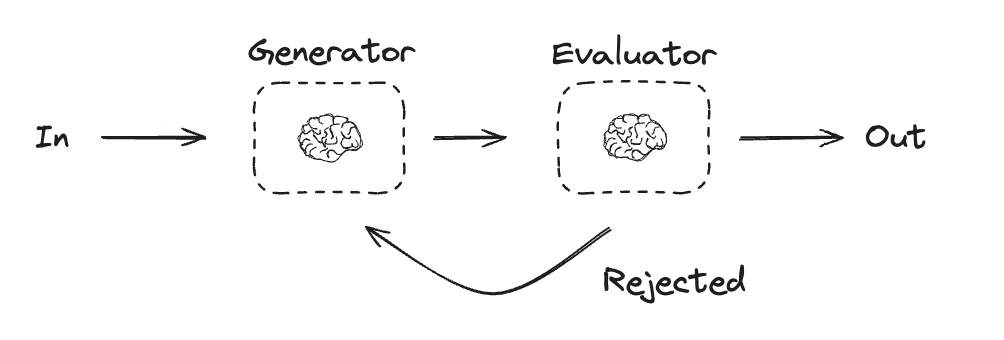

两个核心组件：
- 生成器（Generator）：产出内容
- 评估器（Evaluator）：打分/给出反馈 --> 如果不达标就带着反馈重新生成

形成一个质量提升的闭环。

与普通循环的区别：循环自带"质量门"，只在质量不达标时才重复，避免了无谓的循环。

典型场景: 文案优化（生成→评分→改写）、代码审查（生成→检查→修复）、翻译质量提升。

示例，我们写一个生成广告语的工作流：

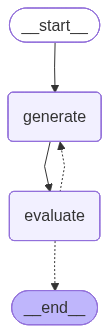

In [14]:
# Evaluator-Optimizer: 生成广告语 → 评估 → 不达标则带着反馈重写
from typing import Literal

class AdState(TypedDict):
    product: str        # 产品名称
    slogan: str         # 当前广告语
    feedback: str       # 评估反馈
    grade: str          # 评分: "good" 或 "bad"
    iteration: int      # 当前迭代次数

# 模拟评估器（实际使用时用 llm.with_structured_output）
def evaluator_node(state: AdState):
    """评估广告语质量"""
    slogan = state["slogan"]
    iteration = state.get("iteration", 0)

    # 模拟评估逻辑：检查是否包含关键要素
    checks = []
    if len(slogan) < 10:
        checks.append("太短了，不够吸引人")
    if state["product"] not in slogan:
        checks.append(f"没有提到产品名'{state['product']}'")
    if "！" not in slogan and "!" not in slogan and "？" not in slogan:
        checks.append("缺少情感标点，不够有感染力")

    if not checks:
        return {"grade": "good", "feedback": ""}
    return {"grade": "bad", "feedback": "；".join(checks)}

def generate_slogan(state: AdState):
    """生成/改进广告语"""
    feedback = state.get("feedback", "")
    iteration = state.get("iteration", 0) + 1

    if feedback:
        print(f"  [第{iteration}轮] 根据反馈改进: {feedback}")
        # 模拟改进：根据反馈加长、加产品名、加感叹号
        new_slogan = f"🔥 {state['product']} 好啊！真滴棒！{state['product']} 好啊！顶呱呱！"
    else:
        new_slogan = f"{state['product']}真好"  # 故意生成一个不合格的
        print(f"  [第{iteration}轮] 初版生成: {new_slogan}")

    return {"slogan": new_slogan, "iteration": iteration}

def route_after_eval(state: AdState) -> Literal["generate", "__end__"]:
    """评估后路由：good→结束，bad→重新生成，超过3轮强制终止"""
    if state["grade"] == "good":
        print(f"  ✓ 评估通过！最终版本: {state['slogan']}")
        return END
    if state.get("iteration", 0) >= 3:
        print(f"  ⚠ 达到最大迭代次数，强制终止")
        return END
    return "generate"

eval_opt_graph = (
    StateGraph(AdState)
    .add_node("generate", generate_slogan)
    .add_node("evaluate", evaluator_node)
    .add_edge(START, "generate")
    .add_edge("generate", "evaluate")
    .add_conditional_edges("evaluate", route_after_eval, {
        "generate": "generate",  # 不达标→回generate重写
        END: END
    })
    .compile()
)

display_graph(eval_opt_graph)

In [16]:
print("=== Evaluator-Optimizer: 广告语生成 ===\n")
r = eval_opt_graph.invoke({
    "product": "汇源肾宝片", "slogan": "", "feedback": "", "grade": "", "iteration": 0
})
print(f"\n最终广告语: {r['slogan']}")
print(f"总共迭代: {r['iteration']} 轮")

=== Evaluator-Optimizer: 广告语生成 ===

  [第1轮] 初版生成: 汇源肾宝片真好
  [第2轮] 根据反馈改进: 太短了，不够吸引人；缺少情感标点，不够有感染力
  ✓ 评估通过！最终版本: 🔥 汇源肾宝片 好啊！真滴棒！汇源肾宝片 好啊！顶呱呱！

最终广告语: 🔥 汇源肾宝片 好啊！真滴棒！汇源肾宝片 好啊！顶呱呱！
总共迭代: 2 轮


## 6. 子图嵌套（Subgraphs）

复杂的工作流太过庞大不利于维护，此时可以拆分为多层子图。LangGraph 支持将 已编译的子图作为父图的一个Node 直接使用。

包括两种使用方式：
| 方式 | API | 特点 |
| --- | --- | --- |
| 直接嵌入 | add_node("name", compiled_subgraph) | 子图作为图节点，checkpoint与父图集成，interrupt自动向上冒泡 |
| 包装调用 | 在普通node函数内 subgraph.invoke() | 灵活的状态映射，需手动传递数据 |
若采用嵌入模式，且父图的State与子图的State共享某些key时：
- 父→子: 父图自动将共享key的值传给子图（input projection）
- 子→父: 子图返回的key如果父图也有，则按父图的reducer写回

如果父子图State完全不同，需要用包装调用方式手动映射。

### 6.1 直接嵌入
我们做一个舆情检测类的工作流
- 父图：负责收集数据、汇总结果
- 子图：负责情感分析、关键词提取

以下是示例代码：

首先State：

In [17]:
# ========== 方式1: 直接嵌入 compiled subgraph ==========
# 子图和父图共享 State key，父图自动完成状态映射

# ----- 父图: 将来直接把子图嵌入作为节点 -----
class ParentState(TypedDict):
    input_text: str     # 可共享，父调用子时直接会传递给子图
    result: str         # 子返回结果时，会直接返回给父图
    preprocessed: str
    final_output: str

# ----- 子图: 情感分析子流程（独立编译）-----
class AnalysisSubState(TypedDict):
    """子图State——除了共享key，还可以有自己的key"""
    input_text: str     # 父调用子时直接传递给子图
    result: str         # 子返回结果时，直接返回给父图
    sentiment: str      # 子图私有key
    keywords: str       # 子图私有key

然后是子图（Subgraph）：

In [18]:
# ========== 方式1: 直接嵌入 compiled subgraph ==========

def detect_sentiment(state: AnalysisSubState):
    """节点1: 检测情感"""
    text = state["input_text"]
    positive_words = ["好", "棒", "喜欢", "赞", "优秀", "nice"]
    score = sum(1 for w in positive_words if w in text)
    sentiment = "正面 😊" if score > 0 else "负面/中性 😐"
    print(f"    [子图-情感分析] sentiment={sentiment}")
    return {"sentiment": sentiment}


def extract_keywords(state: AnalysisSubState):
    """节点2: 提取关键词"""
    # 模拟实现
    text = state["input_text"]
    kw = text[:30] + ("..." if len(text) > 30 else "")
    print(f"    [子图-关键词] keywords={kw}")
    return {"keywords": kw}

def aggregator(state: AnalysisSubState):
    """节点3: 合并结果"""
    print(f"    [子图-合并结果] result=..")
    return {"result": f"情感:{state['sentiment']}, 关键词:{state['keywords']}"}

# 编译子图
analysis_subgraph = (
    StateGraph(AnalysisSubState)
    .add_node("sentiment", detect_sentiment)
    .add_node("keywords", extract_keywords)
    .add_node("aggregator", aggregator)
    .add_edge(START, "sentiment")
    .add_edge(START, "keywords")
    .add_edge("sentiment", "aggregator")
    .add_edge("keywords", "aggregator")
    .add_edge("aggregator", END)
    .compile()
)

接着是父图：


=== XRay模式（展开子图内部）===


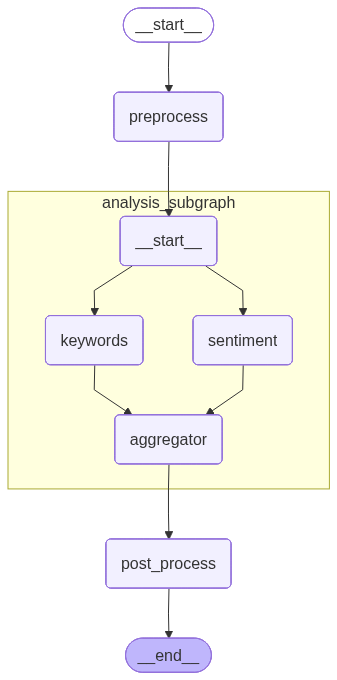

In [20]:
# ----- 父图: 直接嵌入子图作为节点 -----
def preprocess(state: ParentState):
    print(f"  [父图-预处理] 收到: {state['input_text'][:40]}...")
    return {"preprocessed": state["input_text"]}

def post_process(state: ParentState):
    print(f"  [父图-后处理] 子图结果: {state['result']}")
    return {"final_output": f"✅ 处理完成: {state['result']}"}

# 🔑 关键：直接把编译好的子图传给 add_node
parent_graph = (
    StateGraph(ParentState)
    .add_node("preprocess", preprocess)
    .add_node("analysis_subgraph", analysis_subgraph)  # 子图作为节点！
    .add_node("post_process", post_process)
    .add_edge(START, "preprocess")
    .add_edge("preprocess", "analysis_subgraph")
    .add_edge("analysis_subgraph", "post_process")
    .add_edge("post_process", END)
    .compile()
)
# 用 xray 模式可以看到子图内部结构
print("\n=== XRay模式（展开子图内部）===")
display_graph(parent_graph, xray=True)

可以看到，子图的名字是：analysis_subgraph，子图成为了父的节点

In [21]:
# 测试：直接嵌入子图的父图
print("=== 测试直接嵌入子图 ===\n")
r = parent_graph.invoke({
    "input_text": "这个产品真好用，我很喜欢！",
    "preprocessed": "",
    "result": "",
    "final_output": ""
})
print(f"\n最终输出: {r['final_output']}")

=== 测试直接嵌入子图 ===

  [父图-预处理] 收到: 这个产品真好用，我很喜欢！...
    [子图-关键词] keywords=这个产品真好用，我很喜欢！
    [子图-情感分析] sentiment=正面 😊
    [子图-合并结果] result=..
  [父图-后处理] 子图结果: 情感:正面 😊, 关键词:这个产品真好用，我很喜欢！

最终输出: ✅ 处理完成: 情感:正面 😊, 关键词:这个产品真好用，我很喜欢！


### 6.2 包装调用
还是刚才的案例，但我们采用包装调用的方式，这样一来，不管State字段是否一样，父子图之间就无法共享数据，必须手动调用，手动传递。

子图保持不变，此处略。

接着是父图，这一次我们故意将父图的State字段改成与子图不一致：


=== XRay模式（展开子图内部）===


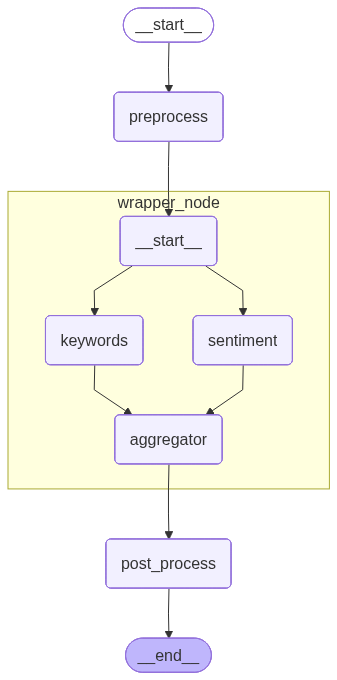

In [22]:
# ----- 父图: 直接把子图嵌入作为节点 -----
class ParentStateV2(TypedDict):
    query: str     # 无法共享，父调用子时直接会传递给子图的input_text
    answer: str         # 无法共享，子返回result结果时，需手动传给父图
    preprocessed: str
    final_output: str

def wrapper_node(state: ParentStateV2):
    """在包装函数内手动做 State 映射"""
    # 父→子：手动映射
    sub_result = analysis_subgraph.invoke({"input_text": state["query"]})
    # 子→父：手动映射
    return {"answer": f"包装调用结果: {sub_result['result']}"}


def preprocess(state: ParentStateV2):
    print(f"  [父图-预处理] 收到: {state['query'][:40]}...")
    return {"preprocessed": state["query"]}

def post_process(state: ParentStateV2):
    print(f"  [父图-后处理] 子图结果: {state['answer']}")
    return {"final_output": f"✅ 处理完成: {state['answer']}"}

# 🔑 关键：直接把编译好的子图传给 add_node
parent_graph_v2 = (
    StateGraph(ParentStateV2)
    .add_node("preprocess", preprocess)
    #.add_node("analysis_subgraph", analysis_subgraph)
    .add_node("wrapper_node", wrapper_node)
    .add_node("post_process", post_process)
    .add_edge(START, "preprocess")
    .add_edge("preprocess", "wrapper_node")
    .add_edge("wrapper_node", "post_process")
    .add_edge("post_process", END)
    .compile()
)
# 用 xray 模式可以看到子图内部结构
print("\n=== XRay模式（展开子图内部）===")
display_graph(parent_graph_v2, xray=True)

可以看到，子图的名字已经是wrapper_node了，不是子图原本的名字，这就是包装调用。
测试：

In [23]:
# 测试：直接嵌入子图的父图
print("=== 测试包装调用子图 ===\n")
r = parent_graph_v2.invoke({
    "query": "这个产品真好用，我很喜欢！",
    "answer": "",
    "preprocessed": "",
    "final_output": ""
})
print(f"\n最终输出: {r['final_output']}")

=== 测试包装调用子图 ===

  [父图-预处理] 收到: 这个产品真好用，我很喜欢！...
    [子图-关键词] keywords=这个产品真好用，我很喜欢！
    [子图-情感分析] sentiment=正面 😊
    [子图-合并结果] result=..
  [父图-后处理] 子图结果: 包装调用结果: 情感:正面 😊, 关键词:这个产品真好用，我很喜欢！

最终输出: ✅ 处理完成: 包装调用结果: 情感:正面 😊, 关键词:这个产品真好用，我很喜欢！


## 7. 总结

七种编排模式速查

| 模式 | API | 原理 | 典型场景 |
| --- | --- | --- | --- |
| Prompt Chaining | add_edge 串联 + add_conditional_edges 做门控 | 每个LLM输出作下一个LLM输入，中间可插入质检 | 写作流程、翻译+校对、分步推理 |
| Routing | add_conditional_edges(node, router, mapping) | router函数返回节点名，mapping映射到实际节点 | 意图路由、权限分流、LLM工具调用判断 |
| Parallelization | 多条add_edge指向不同目标 | 节点间无依赖即可并行，需要reducer合并结果 | 同时查多个数据源、并行LLM调用 |
| Orchestrator-Worker | add_conditional_edges + Send API | 动态生成Send列表，并行分发到同一节点不同State | 批量处理、子问题分解、分布式搜索 |
| Evaluator-Optimizer | 条件边回环 + 评估器门控 | 生成→评估→不达标带反馈重写，达标则退出 | 文案优化、代码审查、翻译质量提升 |
| 子图嵌套 | add_node("name", compiled_subgraph) 或包装调用 | 子图独立管理内部State和控制流，父图复用完整流程 | 复杂流程分层、可复用流程组件 |

核心要点

1. Prompt Chaining 是最简单的编排 — 串联LLM调用，中间加入门控检查，形成可验证的流水线
2. 路由是智能的基础 — Agent通过add_conditional_edges根据State动态选择路径
3. 并行提升性能 — 无依赖的节点可并行执行，用operator.add等reducer合并结果
4. Orchestrator-Worker — 动态任务拆分与并行执行，是智能与效率的结合，需要Send API
5. Evaluator-Optimizer保障质量 — 生成→评估→反馈→重写循环，直到达标
6. 子图实现分层设计 — 复杂流程拆为独立子图，add_node(graph)直接嵌入，共享State自动映射

模式选择指南

- 确定步骤顺序 → Prompt Chaining
- 存在不同领域的Node → 智能路由(Routing)
- 多个独立任务加速 → 并行执行(Parallelization)
- 复杂任务动态拆分和性能提升 → Orchestrator-Worker(Send)
- 需要迭代优化质量 → Evaluator-Optimizer
- 流程太长需要拆解 → 子图嵌套